# Notebooks intéractifs

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# le driver ipympl
%matplotlib ipympl

- Recherche du nombre d'or avec une précision de $10^{-6}$

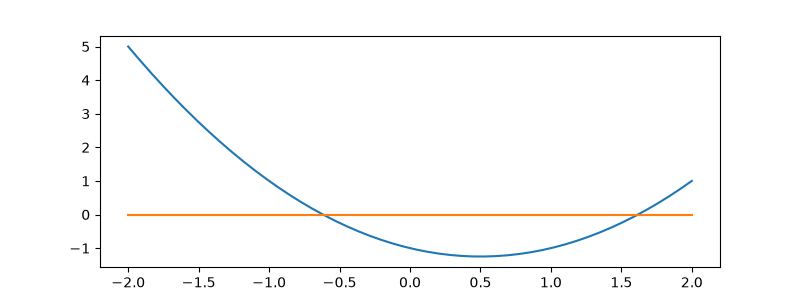

In [ ]:
plt.figure(figsize=(8, 3))
X = np.linspace(-2, 2)
ZERO = X * 0
def golden(x):
    return x**2 - x - 1
plt.plot(X, golden(X));
plt.plot(X, ZERO);

## Visualisation interactive avec `interact`

### Visualisation d'un oscilloscope virtuel 

Animer une fonction sinus, avec un bouton pour régler la fréquence.

La fonction interact est un utilitaire qui fait partie de l’écosystème des notebooks, et plus précisément du module ipywidgets.

In [6]:
from ipywidgets import interact

interactive(children=(FloatSlider(value=5.25, description='freq', max=10.0, min=0.5, step=0.25), Output()), _d…

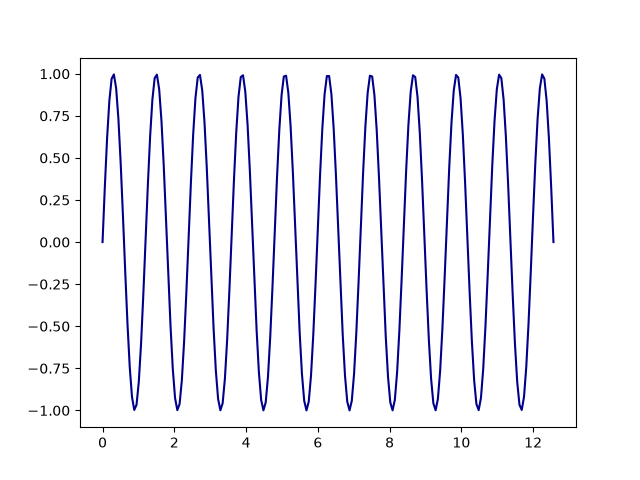

In [14]:
# créer une figure - et trouver les axes
# on le fait une seule fois - et donc pas dans la fonction sinus
fig, ax = plt.subplots()

# cette fonction va être appelée sans arrêt
# son job est de nettoyer la courbe précédente
# et d'afficher la nouvelle pour freq
def sinus(freq):
    # le domaine en X
    X = np.linspace(0., 4*np.pi, 200)
    # les Y
    Y = np.sin(freq*X)

    # nettoyer la ligne précédente
    for line in ax.lines:
        line.remove()
    # dessiner la courbe pour freq
    # (on précise une couleur, sinon mpl en choisit
    # une au hasard à chaque fois, c'est vilain..)
    ax.plot(X, Y, color='DarkBlue')

# et maintenant le morceau de bravoure
# on affiche un "slider" - une réglette - qui réappelle 'sinus'
# à chaque changement de la valeur de 'freq'

interact(sinus, freq=(0.5, 10., 0.25));

# voyez comment vous pouvez choisir 'freq' avec la réglette


Le mécanisme général, c’est que la fonction interact s’attend à recevoir :

- en premier argument : une fonction f ;

- et ensuite autant d’arguments nommés supplémentaires que de paramètres attendus par f.

### Les objets `Slider`

In [8]:
from ipywidgets import FloatSlider

interactive(children=(FloatSlider(value=0.5, description='freq', max=10.0, min=0.5, step=0.25), Output()), _do…

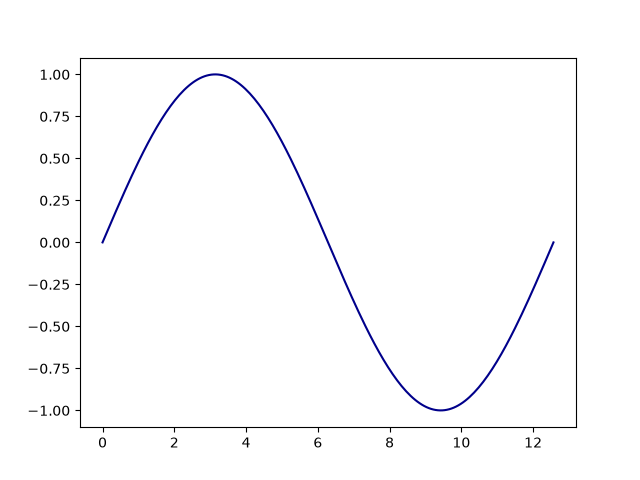

In [10]:
fig, ax = plt.subplots()

interact(sinus, freq=FloatSlider(min=0.5, max=10, step=0.25));

interactive(children=(FloatSlider(value=1.0, continuous_update=False, description='Fréquence', max=10.0, min=0…

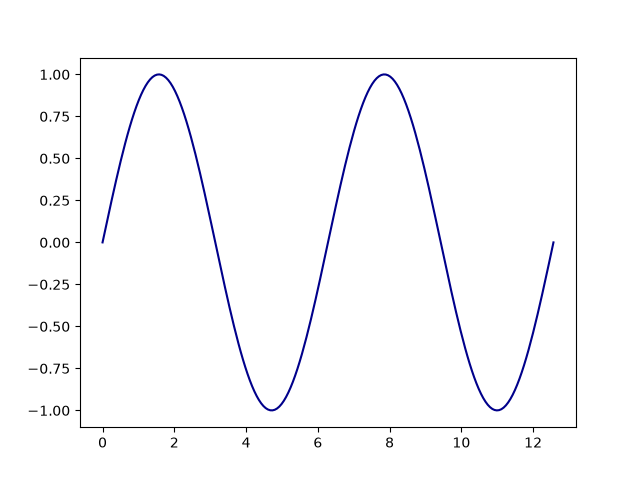

In [16]:
fig, ax = plt.subplots()

interact(sinus, freq=FloatSlider(min=0.5, max=10, step=0.25, value=1.0, description='Fréquence', continuous_update=False));

interactive(children=(FloatSlider(value=1.0, description='Fréquence', max=10.0, min=0.5, step=0.25), FloatSlid…

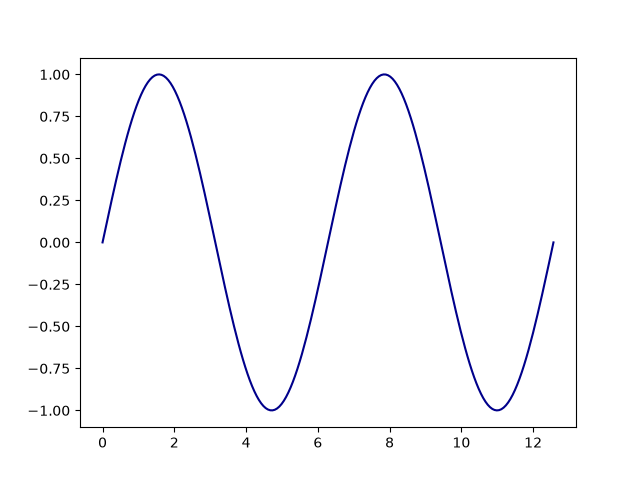

In [19]:
fig, ax = plt.subplots()

def sinus2(freq, phase):
    X = np.linspace(0., 4*np.pi, 200)
    Y = np.sin(freq * (X + phase))

    for line in ax.lines:
        line.remove()

    ax.plot(X, Y, color='DarkBlue')

interact(sinus2, 
         freq=FloatSlider(min=0.5, max=10, step=0.25, value=1.0, description='Fréquence'), 
         phase=FloatSlider(min=0., max=2*np.pi, step=np.pi/6, description='Phase'));

### Bouche-trou : `fixed`

Si j’ai une fonction qui prend plus de paramètres que je ne veux montrer de réglettes, je peux fixer un des paramètres en utilisant l’utilitaire fixed; c’est comme si on créait une réglette avec une valeur fixe, du coup on n’a même pas besoin de montrer cette réglette.



In [20]:
from ipywidgets import fixed

interactive(children=(FloatSlider(value=0.0, description='phase', max=6.283185307179586, step=0.52359877559829…

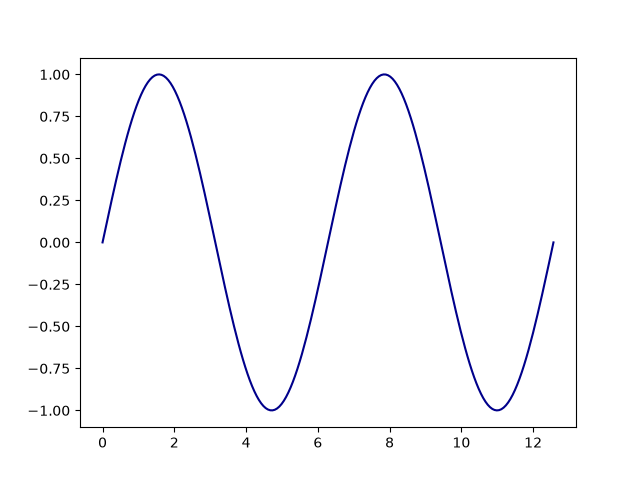

In [21]:
fig, ax = plt.subplots()

interact(sinus2, 
         freq=fixed(1), 
         phase=FloatSlider(min=0., max=2*np.pi, step=np.pi/6));

### Widgets

- créer un radio bouton pour entrer un paramètre booléen ;
- ou une saisie de texte pour entre un paramètre de type `str` ;
- ou une liste à choix multiples…

interactive(children=(Dropdown(description='freq', options={'rapide': 10.0, 'moyenne': 1.0, 'lente': 0.1}, val…

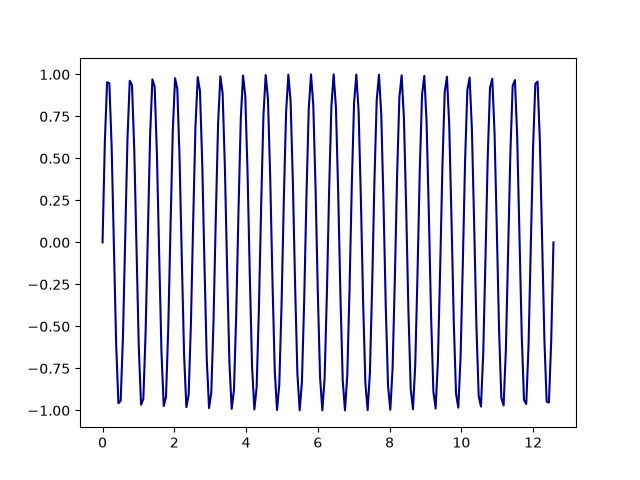

In [24]:
fig, ax = plt.subplots()

interact(sinus, 
         freq={'rapide': 10., 'moyenne': 1., 'lente': 0.1});

### La forme avec un décorateur

Il est possible également d’utiliser interact comme un décorateur, qui donne une forme un tout petit peu plus concise

interactive(children=(FloatSlider(value=5.25, description='freq', max=10.0, min=0.5, step=0.25), Output()), _d…

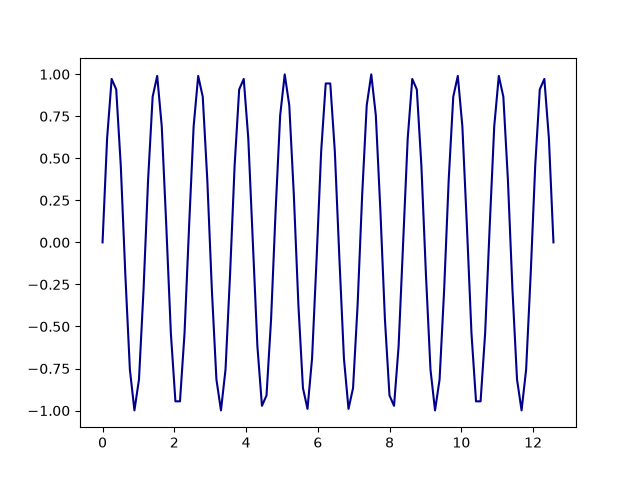

In [25]:
fig, ax = plt.subplots()

@interact(freq=(0.5, 10., 0.25))
def sinus(freq):
    X = np.linspace(0., 4*np.pi, 100)
    Y = np.sin(freq * X)

    for line in ax.lines:
        line.remove()
    
    ax.plot(X, Y, color='DarkBlue')